# CSP Programming Assignment Bonus: Sudoku Solver

**Problem chosen:** Sudoku Solver  
**Course:** ICOM5015 - Artificial Intelligence  
**Students:** Francisco Pico, Cristian Ballester


## 1. Purpose

The purpose of this project is to design, implement, and evaluate a Sudoku solver using a Constraint Satisfaction Problem (CSP) formulation. Sudoku is a good CSP problem because the objective is not to maximize a score, but to assign valid values to a set of variables while satisfying constraints. Each empty cell must receive a digit from 1 to 9, and the final board must obey the Sudoku rules for rows, columns, and 3 × 3 boxes.

The goal of this assignment is not only to make the solver work. The goal is to explain the CSP formulation, compare possible backtracking improvements, implement the approach that is most effective, and test it across at least three difficulty levels.


## 2. Key Questions

This project answers the following questions:

1. How can Sudoku be represented as a CSP?
2. What are the variables, domains, and constraints?
3. Which constraints are unary, binary, higher order, or global?
4. Which backtracking improvements reduce computation time and detect failing paths earlier?
5. Does the selected algorithm solve easy, medium, and hard Sudoku puzzles efficiently?


## 3. Rules and Scope Used

This implementation uses the standard 9 × 9 Sudoku rules.

**Rules included:**

- The board has 81 cells arranged in 9 rows and 9 columns.
- Each cell must contain one digit from 1 to 9.
- Each row must contain digits 1 to 9 without repetition.
- Each column must contain digits 1 to 9 without repetition.
- Each 3 × 3 box must contain digits 1 to 9 without repetition.
- Given numbers in the original puzzle are fixed and cannot be changed.

**Scope decision:**

The notebook focuses on solving valid Sudoku puzzles using CSP techniques. It does not generate new Sudoku puzzles or prove uniqueness beyond checking that the returned solution satisfies all constraints.


## 4. Library Use

This notebook uses:

- `collections.deque` for the AC-3 queue.
- `time.perf_counter` for timing experiments.
- `statistics` for average solving time.
- `pandas` for organizing results in tables.
- `matplotlib` for plotting evaluation results.



## 5. Imports


In [1]:
from collections import deque
from time import perf_counter
import statistics
import pandas as pd
import matplotlib.pyplot as plt


## 6. CSP Model

Sudoku is modeled as a CSP using the following components.

### Variables

Each cell in the 9 × 9 grid is a variable. In the code, variables are named using row letters and column numbers, such as `A1`, `A2`, and `I9`.

### Domains

Each variable has a domain of possible values. For an empty cell, the starting domain is `{1,2,3,4,5,6,7,8,9}`. For a fixed clue, the domain contains only that clue.

### Constraints

The main rule is that cells in the same row, column, or 3 × 3 box cannot have the same value.

| Constraint Type | Sudoku Example | How it appears here |
|---|---|---|
| Unary | A given cell is already fixed, such as `A1 = 5` | Fixed clue creates a one value domain |
| Binary | Two peer cells cannot be equal, such as `A1 != A2` | Used by AC-3 arcs |
| Higher order | A row, column, or box contains multiple cells that interact | The unit contains 9 related cells |
| Global | All cells in a row, column, or box must be all different | Enforced as pairwise not-equal constraints |

Although Sudoku is naturally a 9 × 9 grid, each puzzle is written as an 81 character string for compact input. The string is read row by row from left to right. The program then converts it into a dictionary of CSP variables and domains.


In [2]:
ROWS = "ABCDEFGHI"
COLS = "123456789"
DIGITS = set("123456789")
CELLS = [r + c for r in ROWS for c in COLS]

def cross(A, B):
    """Return all combinations of items from A and B."""
    return [a + b for a in A for b in B]

# Units: 9 rows, 9 columns, and 9 boxes.
ROW_UNITS = [cross(r, COLS) for r in ROWS]
COL_UNITS = [cross(ROWS, c) for c in COLS]
BOX_UNITS = [cross(rs, cs) for rs in ("ABC", "DEF", "GHI") for cs in ("123", "456", "789")]
UNITS = ROW_UNITS + COL_UNITS + BOX_UNITS

# For each cell, find the units it belongs to and all peer cells related by constraints.
UNITS_OF = {cell: [unit for unit in UNITS if cell in unit] for cell in CELLS}
PEERS = {cell: set(sum(UNITS_OF[cell], [])) - {cell} for cell in CELLS}

# Each binary constraint is represented as an arc Xi != Xj.
ARCS = [(xi, xj) for xi in CELLS for xj in PEERS[xi]]

print(f"Variables: {len(CELLS)}")
print(f"Units: {len(UNITS)}")
print(f"Directed arcs for AC-3: {len(ARCS)}")


Variables: 81
Units: 27
Directed arcs for AC-3: 1620


## 7. Puzzle Parsing and Display

The function below converts the compact puzzle string into the CSP representation.

- Digits `1` to `9` are fixed clues.
- `0` or `.` means the cell is empty.
- The result is a dictionary where each key is a cell and each value is that cell's domain.

For example, the first character of the string is cell `A1`, the second is `A2`, and the last is `I9`.


In [3]:
def parse_grid(grid):
    """
    Convert an 81-character Sudoku string into a domain dictionary.
    Digits 1-9 are fixed clues.
    0 or . means the cell is empty.
    """
    chars = [c for c in grid if c in "1234567890."]

    if len(chars) != 81:
        raise ValueError(f"Grid must contain exactly 81 cells, but got {len(chars)}.")

    domains = {}
    for cell, char in zip(CELLS, chars):
        if char in "123456789":
            domains[cell] = {char}
        else:
            domains[cell] = set(DIGITS)

    return domains


def display_grid(domains):
    """Pretty-print a Sudoku grid from a domain dictionary."""
    if domains is None:
        print("No solution found.")
        return

    width = 1 + max(len(domains[cell]) for cell in CELLS)
    line = "+".join(["-" * (width * 3)] * 3)

    for r in ROWS:
        row = ""
        for c in COLS:
            cell = r + c
            value = "".join(sorted(domains[cell]))
            row += value.center(width)
            if c in "36":
                row += "|"
        print(row)
        if r in "CF":
            print(line)


def is_solved(domains):
    """Return True if every cell has exactly one value."""
    return domains is not None and all(len(domains[cell]) == 1 for cell in CELLS)


def valid_solution(domains):
    """Check whether the final assignment satisfies all Sudoku units."""
    if not is_solved(domains):
        return False

    for unit in UNITS:
        values = [next(iter(domains[cell])) for cell in unit]
        if set(values) != DIGITS:
            return False

    return True


def solution_string(domains):
    """Convert a solved domain dictionary back to an 81-character string."""
    if domains is None:
        return None
    return "".join(next(iter(domains[cell])) for cell in CELLS)


## 8. Solver Design

This project compares several possible solving approaches before implementing the strongest one.

| Approach | Main Idea | Strength | Limitation |
|---|---|---|---|
| Plain backtracking | Try values and undo choices when they fail | Simple and correct | Can waste time exploring bad paths |
| Forward checking | Remove impossible values from neighbors after an assignment | Detects some failures early | Does not fully propagate constraints |
| MRV heuristic | Choose the cell with the fewest legal values | Reduces branching | Still needs value ordering |
| Degree heuristic | Break MRV ties by choosing the most constrained cell | Improves variable choice | Only a tie breaker |
| LCV heuristic | Try values that eliminate the fewest neighbor options first | Reduces early conflicts | Has small extra computation cost |
| AC-3 | Enforce arc consistency before and during search | Strong early pruning | Does not always solve the puzzle alone |

**Implemented approach:**

The implemented solver uses **AC-3 + Backtracking Search + MRV + Degree Heuristic + LCV**. This was chosen because it combines early failure detection with intelligent variable and value ordering.


## 9. Constraint Propagation with AC-3

AC-3 checks binary constraints between pairs of peer cells. In this Sudoku solver, the binary rule is:

\[
X_i 
e X_j
\]

If one cell already has a single value, that value can be removed from the domains of its peers. If any domain becomes empty, the current path is impossible and the solver can stop exploring it.


In [4]:
def revise(domains, xi, xj, stats):
    """
    Revise the domain of Xi using Xj.

    Since the Sudoku binary constraint is Xi != Xj:
    if Xj has only one possible value, remove that value from Xi.
    """
    revised = False

    if len(domains[xj]) == 1:
        forbidden_value = next(iter(domains[xj]))

        if forbidden_value in domains[xi]:
            domains[xi] = domains[xi] - {forbidden_value}
            stats["eliminations"] += 1
            revised = True

    return revised


def ac3(domains, queue=None, stats=None):
    """
    AC-3 algorithm for arc consistency.
    Returns False if a domain becomes empty.
    Returns True if arc consistency is achieved.
    """
    if stats is None:
        stats = {"eliminations": 0, "arc_checks": 0}

    q = deque(ARCS if queue is None else queue)

    while q:
        xi, xj = q.popleft()
        stats["arc_checks"] += 1

        if revise(domains, xi, xj, stats):
            if len(domains[xi]) == 0:
                return False

            for xk in PEERS[xi] - {xj}:
                q.append((xk, xi))

    return True


## 10. Backtracking Search

After AC-3 reduces the domains, backtracking search finishes the puzzle if there are still cells with multiple possible values.

Important design decisions:

- **MRV:** choose the unassigned cell with the smallest domain first.
- **Degree heuristic:** if there is a tie, choose the cell that constrains the most other unassigned cells.
- **LCV:** try the value that removes the fewest options from neighboring cells first.
- **Forward checking with AC-3:** after a tentative assignment, propagate the effect to related cells before going deeper.


In [ ]:
def select_unassigned_variable(domains):
    """
    Choose the next variable using:
    1. MRV: minimum remaining values.
    2. Degree heuristic as tie breaker: most unassigned peers.
    """
    unassigned = [cell for cell in CELLS if len(domains[cell]) > 1]

    return min(
        unassigned,
        key=lambda cell: (
            len(domains[cell]),
            -sum(1 for peer in PEERS[cell] if len(domains[peer]) > 1)
        )
    )


def order_domain_values(domains, variable):
    """
    Order values using LCV:
    choose values that eliminate the fewest options from neighboring cells first.
    """
    return sorted(
        domains[variable],
        key=lambda value: sum(1 for peer in PEERS[variable] if value in domains[peer])
    )


def backtrack(domains, stats, depth=0):
    """Backtracking search with MRV, Degree, LCV, and AC-3 propagation."""
    stats["max_depth"] = max(stats["max_depth"], depth)

    if is_solved(domains):
        return domains

    variable = select_unassigned_variable(domains)

    for value in order_domain_values(domains, variable):
        stats["nodes"] += 1

        new_domains = {cell: set(domains[cell]) for cell in CELLS}
        new_domains[variable] = {value}

        # Only arcs affected by this new assignment need to be reconsidered.
        affected_arcs = [(peer, variable) for peer in PEERS[variable]]

        if ac3(new_domains, queue=affected_arcs, stats=stats):
            result = backtrack(new_domains, stats, depth + 1)
            if result is not None:
                return result

        stats["backtracks"] += 1

    return None


def solve(grid):
    """Solve one Sudoku puzzle and return the solution plus performance statistics."""
    stats = {
        "nodes": 0,
        "backtracks": 0,
        "eliminations": 0,
        "arc_checks": 0,
        "max_depth": 0
    }

    domains = parse_grid(grid)
    start = perf_counter()

    result = None
    if ac3(domains, stats=stats):
        result = backtrack(domains, stats)

    stats["time_seconds"] = perf_counter() - start
    stats["solved"] = valid_solution(result)

    return result, stats


## 11. Test Puzzles

The solver is tested using three Sudoku difficulty levels: **Easy**, **Medium**, and **Hard**.

Each puzzle is stored as an 81 character string. This is only the input format. Once the puzzle is read, the program converts it into a dictionary of variables and domains.

The same solver is used for all difficulties. The difference is that harder puzzles usually have fewer clues and require more search.


In [6]:
PUZZLES = {
    "Easy": {
        "grid": "530070000600195000098000060800060003400803001700020006060000280000419005000080079",
        "description": "Classic easy Sudoku puzzle with many direct implications."
    },
    "Medium": {
        "grid": "030020000000000580000401000900000000050803020000000006000304000048000000000010030",
        "description": "Medium puzzle requiring more search after constraint propagation."
    },
    "Hard": {
        "grid": "000000010400000000020000000000050407008000300001090000300400200050100000000806000",
        "description": "Hard puzzle with few clues and more failing paths."
    }
}

for difficulty, info in PUZZLES.items():
    clues = sum(1 for char in info["grid"] if char in "123456789")
    print(f"{difficulty}: {clues} clues - {info['description']}")


Easy: 30 clues - Classic easy Sudoku puzzle with many direct implications.
Medium: 18 clues - Medium puzzle requiring more search after constraint propagation.
Hard: 17 clues - Hard puzzle with few clues and more failing paths.


## 12. Evaluation Plan

A single puzzle is not enough to evaluate the solver. The assignment requires testing across at least three difficulty levels, so the evaluation uses easy, medium, and hard puzzles.

The following metrics are reported:

- **Solved:** whether the solver produced a valid final board.
- **Average time:** mean solving time over repeated runs.
- **Search nodes:** number of tentative assignments explored.
- **Backtracks:** number of failed paths detected.
- **Eliminations:** number of values removed from domains.
- **Arc checks:** amount of AC-3 consistency work.
- **Max depth:** deepest level reached in recursive search.


## 13. Example Solution Output

The following cell solves each puzzle once and prints the final board and important statistics.


In [7]:
for difficulty, info in PUZZLES.items():
    print()
    print(f"{difficulty} Puzzle")
    solution, stats = solve(info["grid"])
    print(f"Solved: {stats['solved']}")
    print(f"Time: {stats['time_seconds']:.6f} seconds")
    print(f"Nodes: {stats['nodes']}")
    print(f"Backtracks: {stats['backtracks']}")
    print("Solution:")
    display_grid(solution)



Easy Puzzle
Solved: True
Time: 0.002843 seconds
Nodes: 0
Backtracks: 0
Solution:
5 3 4 |6 7 8 |9 1 2 
6 7 2 |1 9 5 |3 4 8 
1 9 8 |3 4 2 |5 6 7 
------+------+------
8 5 9 |7 6 1 |4 2 3 
4 2 6 |8 5 3 |7 9 1 
7 1 3 |9 2 4 |8 5 6 
------+------+------
9 6 1 |5 3 7 |2 8 4 
2 8 7 |4 1 9 |6 3 5 
3 4 5 |2 8 6 |1 7 9 

Medium Puzzle
Solved: True
Time: 0.007003 seconds
Nodes: 38
Backtracks: 11
Solution:
6 3 9 |5 2 8 |1 7 4 
4 1 2 |6 7 9 |5 8 3 
8 7 5 |4 3 1 |2 6 9 
------+------+------
9 6 3 |7 4 2 |8 5 1 
1 5 4 |8 6 3 |9 2 7 
2 8 7 |1 9 5 |3 4 6 
------+------+------
7 2 1 |3 8 4 |6 9 5 
3 4 8 |9 5 6 |7 1 2 
5 9 6 |2 1 7 |4 3 8 

Hard Puzzle
Solved: True
Time: 0.347781 seconds
Nodes: 3287
Backtracks: 3271
Solution:
6 9 3 |7 8 4 |5 1 2 
4 8 7 |5 1 2 |9 3 6 
1 2 5 |9 6 3 |8 7 4 
------+------+------
9 3 2 |6 5 1 |4 8 7 
5 6 8 |2 4 7 |3 9 1 
7 4 1 |3 9 8 |6 2 5 
------+------+------
3 1 9 |4 7 5 |2 6 8 
8 5 6 |1 2 9 |7 4 3 
2 7 4 |8 3 6 |1 5 9 


## 14. Main Results

Each puzzle is solved multiple times, and the average solving time is reported. Multiple runs make the timing more stable, while the number of nodes and backtracks remains deterministic for the same puzzle.


In [8]:
def benchmark(puzzles, repeats=5):
    rows = []

    for difficulty, info in puzzles.items():
        times = []
        latest_stats = None

        for _ in range(repeats):
            solution, stats = solve(info["grid"])
            times.append(stats["time_seconds"])
            latest_stats = stats

        rows.append({
            "Difficulty": difficulty,
            "Clues": sum(1 for char in info["grid"] if char in "123456789"),
            "Solved": latest_stats["solved"],
            "Avg Time (ms)": round(statistics.mean(times) * 1000, 4),
            "Search Nodes": latest_stats["nodes"],
            "Backtracks": latest_stats["backtracks"],
            "Eliminations": latest_stats["eliminations"],
            "Arc Checks": latest_stats["arc_checks"],
            "Max Depth": latest_stats["max_depth"]
        })

    return pd.DataFrame(rows)

results_df = benchmark(PUZZLES, repeats=5)
display(results_df)


,Difficulty,Clues,Solved,Avg Time (ms),Search Nodes,Backtracks,Eliminations,Arc Checks,Max Depth
0,Easy,30,True,2.2179,0,0,408,9372,0
1,Medium,18,True,6.3740,38,11,636,13439,27
2,Hard,17,True,401.3759,3287,3271,46725,613394,24


## 15. Results Plots

The plots below compare the solver's behavior across difficulty levels.

The first plot shows average solving time. The second plot shows how many search nodes were explored. The third plot shows how many backtracks occurred. Together, these plots show how harder puzzles require more search even when constraint propagation is used.


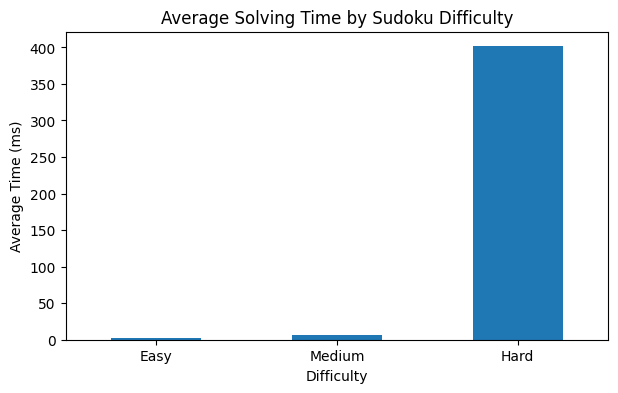

In [9]:
ax = results_df.plot(x="Difficulty", y="Avg Time (ms)", kind="bar", legend=False, figsize=(7, 4))
ax.set_title("Average Solving Time by Sudoku Difficulty")
ax.set_xlabel("Difficulty")
ax.set_ylabel("Average Time (ms)")
plt.xticks(rotation=0)
plt.show()


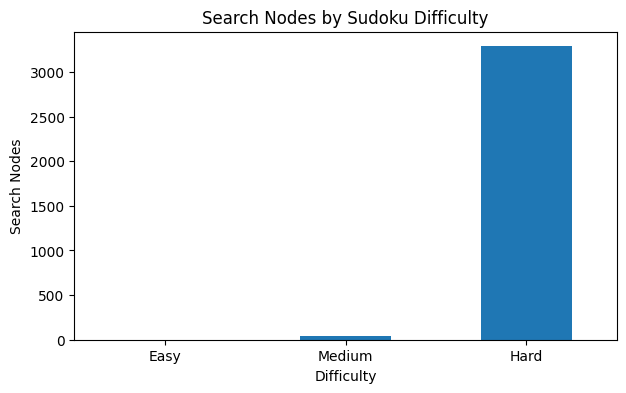

In [10]:
ax = results_df.plot(x="Difficulty", y="Search Nodes", kind="bar", legend=False, figsize=(7, 4))
ax.set_title("Search Nodes by Sudoku Difficulty")
ax.set_xlabel("Difficulty")
ax.set_ylabel("Search Nodes")
plt.xticks(rotation=0)
plt.show()


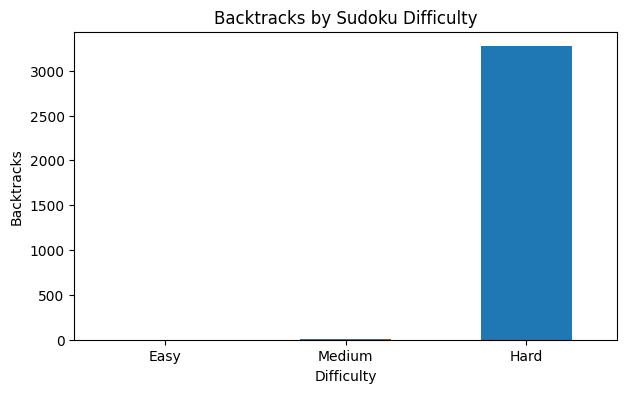

In [11]:
ax = results_df.plot(x="Difficulty", y="Backtracks", kind="bar", legend=False, figsize=(7, 4))
ax.set_title("Backtracks by Sudoku Difficulty")
ax.set_xlabel("Difficulty")
ax.set_ylabel("Backtracks")
plt.xticks(rotation=0)
plt.show()


## 16. Results Analysis

The results show the expected pattern: as Sudoku difficulty increases, the solver usually needs more search.

For the easy puzzle, AC-3 removes enough values that the puzzle is solved without backtracking. This means constraint propagation alone is almost sufficient.

For the medium puzzle, the solver needs some search, but MRV and LCV keep the number of explored nodes manageable. The solver chooses constrained cells early and tries values that are less likely to cause conflicts.

For the hard puzzle, the number of search nodes and backtracks increases significantly. This happens because the puzzle starts with fewer clues, so there are more possible assignments to consider. Even then, the solver is still able to solve the puzzle because AC-3 and the heuristics detect many failing paths before the search becomes too large.


## 17. Limitations

This solver is effective for the tested puzzles, but it has limitations.

1. **No puzzle generation:** The notebook solves given puzzles but does not create new Sudoku boards.
2. **No uniqueness proof:** The solver checks that it found a valid solution, but it does not fully prove that the puzzle has only one solution.
3. **Not a specialized Sudoku only solver:** Some advanced Sudoku strategies used by humans, such as X-Wing or Swordfish, are not implemented.
4. **Harder puzzles can still require many backtracks:** AC-3 and heuristics reduce search, but they do not eliminate the exponential worst case of CSP search.


## 18. Conclusion

This project formulated Sudoku as a CSP with 81 variables, digit domains, and row, column, and box constraints.

After comparing possible approaches, the implemented solver used **AC-3, backtracking search, MRV, the degree heuristic, LCV, and forward checking**. This approach was selected because it reduces unnecessary search, detects failing paths early, and remains easy to explain.

The experiments showed that the solver successfully handled easy, medium, and hard Sudoku puzzles. The easy puzzle was solved mostly through constraint propagation, while the harder puzzles required more search and backtracking. Overall, the results support the idea that CSP techniques are well suited for Sudoku solving.


## References

[1] S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. Pearson, 2021.  

[2] P. Norvig, "Solving Every Sudoku Puzzle," 2006.  

[3] Sudoku.com, "Sudoku Rules for Complete Beginners."
